In [87]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
torch.manual_seed(10000)

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


检查路径

In [88]:
import os
print(os.listdir('AngularPS/processed_tensors/10000'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


导入其余包

In [89]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader

导入数据

In [96]:
def load_data():
    # 加载训练数据
    train_data = torch.load('AngularPS/processed_tensors/10000/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('AngularPS/processed_tensors/10000/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('AngularPS/processed_tensors/10000/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 7200, 'valid': 900, 'test': 990}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

警告：test 数据集样本数量 (1332) 与预期 (990) 不符！
torch.Size([7200, 1, 20, 40])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 900 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1332 样本, 数据形状 torch.Size([1, 20, 40])


定义CNN模型

In [97]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 输入形状 (1, 20, 40)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 输出 (32, 20, 40)
        self.bn1 = nn.BatchNorm2d(32)  # 批归一化
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # 输出 (32, 10, 20)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 输出 (64, 10, 20)
        self.bn2 = nn.BatchNorm2d(64)  # 批归一化
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # 输出 (64, 5, 10)
        self.flatten = nn.Flatten()
        # 计算全连接层输入维度：5 * 10 * 64 = 3200
        self.fc1 = nn.Linear(5 * 10 * 64, 256)  # 更新为3200
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)  # 可根据验证集性能调整到0.1-0.4
        self.fc2 = nn.Linear(256, 2)  # 双输出，回归任务 (klw, mcool)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

定义训练函数

In [98]:
def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

from torchmetrics import R2Score

def train_model(model, train_loader, valid_loader, epochs=100, patience=30, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()
    mae = MeanAbsoluteError().to(device)  # MAE指标
    optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-3)  # 增加weight_decay

    best_valid_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_mae_klw, train_mae_mcool = 0.0, 0.0, 0.0
        valid_r2_klw, valid_r2_mcool = 0.0, 0.0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            optimizer.zero_grad()
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            loss.backward()
            optimizer.step()
            
            # 累积损失和MAE
            train_loss += loss.item() * x.size(0)
            train_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            train_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)

            train_samples += x.size(0)
        
        train_loss /= train_samples
        train_mae_klw /= train_samples
        train_mae_mcool /= train_samples

        # 验证阶段
        model.eval()
        valid_loss, valid_mae_klw, valid_mae_mcool = 0.0, 0.0, 0.0
        valid_samples = 0
        predictions = []
        trues = []

        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)  # output: (batch_size, 2)
                
                # 计算加权验证损失
                loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
                loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
                loss = loss_klw + loss_mcool
                
                valid_loss += loss.item() * x.size(0)
                valid_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
                valid_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
                valid_samples += x.size(0)
                predictions.append(model(x.to(device)).cpu())
                trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae_klw /= valid_samples
        valid_mae_mcool /= valid_samples
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        valid_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        valid_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

        print(f'Epoch {epoch+1}/{epochs}, '
              f'Train Loss: {train_loss:.4f}, Train MAE klw: {train_mae_klw:.4f}, Train MAE mcool: {train_mae_mcool:.4f}, '
              f'Valid Loss: {valid_loss:.4f}, Valid MAE klw: {valid_mae_klw:.4f}, Valid MAE mcool: {valid_mae_mcool:.4f}, '
              f'Valid R2 klw: {valid_r2_klw:.4f}, Valid R2 mcool: {valid_r2_mcool:.4f}')

        valid_r2_total = valid_r2_klw + valid_r2_mcool
        if 'best_valid_r2' not in locals():
            best_valid_r2 = -float('inf')
        if valid_r2_total > best_valid_r2:
            best_valid_r2 = valid_r2_total
            torch.save(model.state_dict(), 'best_model_10000.pt')
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (R2-based)")
                break

    # 加载最佳模型
    model.load_state_dict(torch.load('best_model_10000.pt'))
    return model

定义测试函数

In [99]:
import numpy as np
np.random.seed(100000)

def test_model(model, test_loader, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    criterion = nn.MSELoss()  # 均方误差损失，适用于多输出回归
    mae = MeanAbsoluteError().to(device)  # MAE指标
    test_loss, test_mae_klw, test_mae_mcool = 0.0, 0.0, 0.0
    test_samples = 0
    predictions, trues = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            # 累积损失和MAE
            test_loss += loss.item() * x.size(0)
            test_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            test_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            test_samples += x.size(0)
            
            # 存储预测和真实值
            predictions.append(model(x.to(device)).cpu())  # (batch_size, 2)
            trues.append(y.cpu())  # (batch_size, 2)
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        test_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        test_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

    test_loss /= test_samples
    test_mae_klw /= test_samples
    test_mae_mcool /= test_samples
    predictions = np.concatenate(predictions, axis=0)  # 形状：(N, 2)
    trues = np.concatenate(trues, axis=0)  # 形状：(N, 2)

    print(f'Test Loss: {test_loss:.4f}, Test MAE klw: {test_mae_klw:.4f}, Test MAE mcool: {test_mae_mcool:.4f}, Test R2 klw: {test_r2_klw:.4f}, Test R2 mcool: {test_r2_mcool:.4f}')
    return test_loss, test_mae_klw, test_mae_mcool, predictions, trues

主程序：加载数据、训练和测试

In [24]:
# 加载数据
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = CNN()

# 训练（使用归一化标签，权重设为1.0）
model = train_model(model, train_loader, valid_loader, epochs=100, patience=50, w_klw=1.0, w_mcool=1.0)

# 加载最佳模型
model.load_state_dict(torch.load('best_model_10000.pt'))

# 测试
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/10000/label_stats.pt')
mean, std = label_stats['mean'], label_stats['std']
predictions = predictions * std.numpy() + mean.numpy()
trues = trues * std.numpy() + mean.numpy()

# 打印结果
print("部分测试集预测值与真实值（klw, mcool）：")
for i in range(min(5, len(predictions))):
    print(f"样本 {i+1}: 预测值=[{predictions[i, 0]:.4f}, {predictions[i, 1]:.4e}], "
          f"真实值=[{trues[i, 0]:.4f}, {trues[i, 1]:.4e}]")

torch.Size([7200, 1, 20, 40])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 900 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 900 样本, 数据形状 torch.Size([1, 20, 40])
Epoch 1/100, Train Loss: 1.2646, Train MAE klw: 0.6155, Train MAE mcool: 0.6811, Valid Loss: 1.0515, Valid MAE klw: 0.5471, Valid MAE mcool: 0.6423, Valid R2 klw: 0.5045, Valid R2 mcool: 0.4498
Epoch 2/100, Train Loss: 1.1647, Train MAE klw: 0.5858, Train MAE mcool: 0.6606, Valid Loss: 1.0557, Valid MAE klw: 0.5338, Valid MAE mcool: 0.6402, Valid R2 klw: 0.5039, Valid R2 mcool: 0.4465
Epoch 3/100, Train Loss: 1.1549, Train MAE klw: 0.5827, Train MAE mcool: 0.6598, Valid Loss: 1.0398, Valid MAE klw: 0.5584, Valid MAE mcool: 0.6244, Valid R2 klw: 0.4957, Valid R2 mcool: 0.4670
Epoch 4/100, Train Loss: 1.1327, Train MAE klw: 0.5781, Train MAE mcool: 0.6507, Valid Loss: 1.0389, Valid MAE klw: 0.5564, Valid MAE mcool: 0.6354, Valid R2 klw: 0.5041, Valid R2 mcool: 0.4612
Epoch 5/100, Train Loss: 1.1136, Train MAE kl

测试集参数估计可视化

警告：test 数据集样本数量 (1332) 与预期 (990) 不符！
torch.Size([7200, 1, 20, 40])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 900 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1332 样本, 数据形状 torch.Size([1, 20, 40])


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


Test Loss: 0.7304, Test MAE klw: 0.4512, Test MAE mcool: 0.4782, Test R2 klw: 0.5672, Test R2 mcool: 0.3356


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

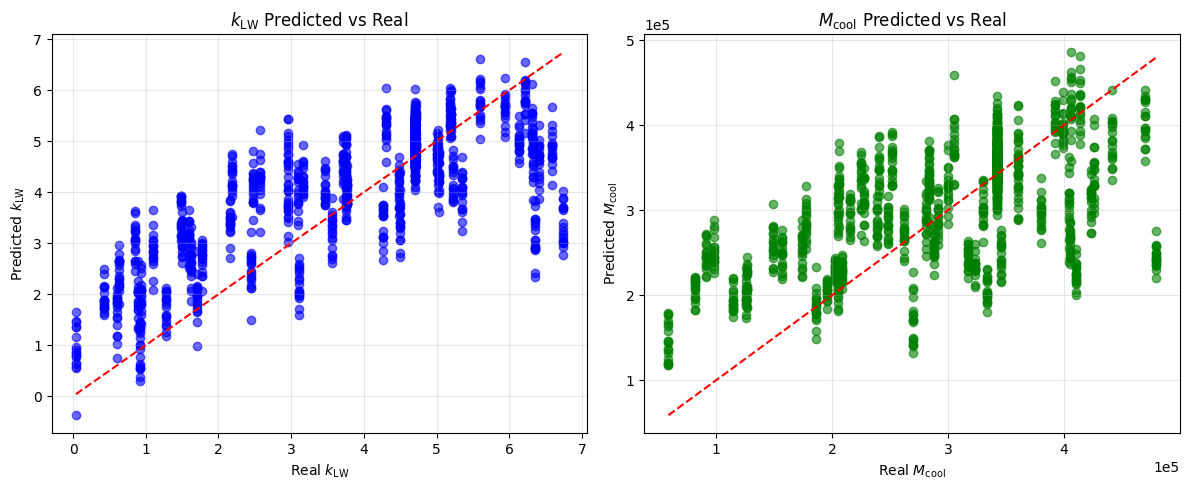

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

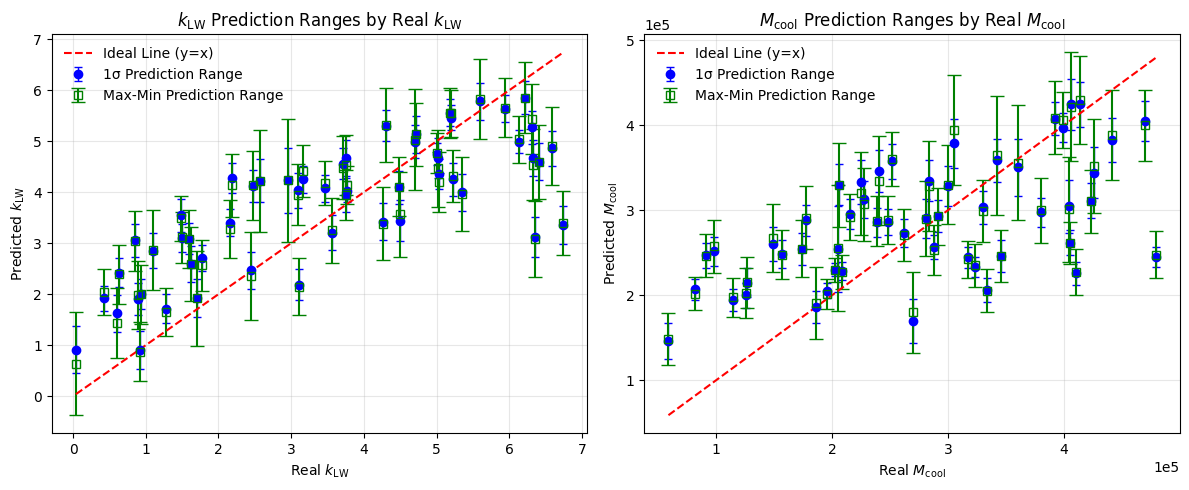

k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：
k_LW_real=0.04: mean=0.9150, 1σ=[0.4607, 1.3693], max-min=[-0.3722, 1.6531] (样本数: 18)
k_LW_real=0.43: mean=1.9237, 1σ=[1.6769, 2.1705], max-min=[1.5962, 2.4980] (样本数: 18)
k_LW_real=0.60: mean=1.6248, 1σ=[1.2565, 1.9932], max-min=[0.7499, 2.1124] (样本数: 18)
k_LW_real=0.63: mean=2.4234, 1σ=[2.1343, 2.7125], max-min=[1.8162, 2.9707] (样本数: 18)
k_LW_real=0.85: mean=3.0547, 1σ=[2.7340, 3.3755], max-min=[2.4581, 3.6260] (样本数: 18)
k_LW_real=0.89: mean=1.8987, 1σ=[1.5864, 2.2110], max-min=[1.3204, 2.6418] (样本数: 18)
k_LW_real=0.92: mean=0.9128, 1σ=[0.5388, 1.2868], max-min=[0.2953, 1.4468] (样本数: 18)
k_LW_real=0.94: mean=2.0005, 1σ=[1.7050, 2.2960], max-min=[1.4226, 2.5723] (样本数: 18)
k_LW_real=1.10: mean=2.8560, 1σ=[2.5063, 3.2056], max-min=[2.0797, 3.6468] (样本数: 18)
k_LW_real=1.28: mean=1.7173, 1σ=[1.4258, 2.0089], max-min=[1.1793, 2.1234] (样本数: 18)
k_LW_real=1.49: mean=3.5461, 1σ=[3.2285, 3.8637], max-min=[3.0496, 3.9325] (样本数: 18)
k_LW_real=1.50: mean=3.1068, 1

In [100]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# MODIFIED: 设置学术论文字体和样式（全局配置）
plt.rcParams['font.size'] = 10  # 默认字体大小10pt
plt.rcParams['axes.titlesize'] = 12  # 标题12pt
plt.rcParams['axes.labelsize'] = 10  # 轴标签10pt
plt.rcParams['xtick.labelsize'] = 10  # x轴刻度10pt
plt.rcParams['ytick.labelsize'] = 10  # y轴刻度10pt
plt.rcParams['legend.fontsize'] = 10  # 图例10pt
plt.rcParams['lines.linewidth'] = 1.5  # 线宽1.5pt
plt.rcParams['lines.markersize'] = 6  # 标记大小6pt

# 加载数据（仅测试集）
_, _, test_loader = load_data()

# 初始化模型并加载最佳权重
model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('best_model_10000.pt'))
model.eval()

# 测试模型，获取预测和真实值
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/10000/label_stats.pt')
mean = label_stats['mean']  # [klw_mean, mcool_mean]
std = label_stats['std']    # [klw_std, mcool_std]
predictions = predictions * std.numpy() + mean.numpy()  # 形状: (900, 2)
trues = trues * std.numpy() + mean.numpy()             # 形状: (900, 2)

# 1. 可视化预测结果：散点图比较预测值 vs 真实值（保持原样，但受益于全局字体）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# k_LW的散点图
axes[0].scatter(trues[:, 0], predictions[:, 0], alpha=0.6, color='blue')
axes[0].plot([trues[:, 0].min(), trues[:, 0].max()], [trues[:, 0].min(), trues[:, 0].max()], 'r--', lw=1.5)
axes[0].set_xlabel('Real $k_{\mathrm{LW}}$')
axes[0].set_ylabel('Predicted $k_{\mathrm{LW}}$')
axes[0].set_title('$k_{\mathrm{LW}}$ Predicted vs Real')
axes[0].grid(True, alpha=0.3)
# M_cool的散点图（使用科学计数法）
axes[1].scatter(trues[:, 1], predictions[:, 1], alpha=0.6, color='green')
axes[1].plot([trues[:, 1].min(), trues[:, 1].max()], [trues[:, 1].min(), trues[:, 1].max()], 'r--', lw=1.5)
axes[1].set_xlabel('Real $M_{\mathrm{cool}}$')
axes[1].set_ylabel('Predicted $M_{\mathrm{cool}}$')
axes[1].set_title('$M_{\mathrm{cool}}$ Predicted vs Real')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_scatter_10000.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 误差棒图：按真实值分组，计算对应预测值的范围（MODIFIED: 添加1sigma std范围）
# 第一张：按真实 k_LW 分组，计算预测 k_LW 的均值、std、max和min
unique_klw_real = np.unique(trues[:, 0])
unique_klw_real.sort()
mean_klw_pred = []  # MODIFIED: 新增均值
std_klw_pred = []   # MODIFIED: 新增标准差
max_klw_pred = []
min_klw_pred = []
sample_counts_klw = []
for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_klw_preds = predictions[mask, 0]
    
    if len(group_klw_preds) > 1:  # MODIFIED: 至少2个样本才能计算std
        mean_klw_pred.append(np.mean(group_klw_preds))
        std_klw_pred.append(np.std(group_klw_preds))  # 1sigma = std
        max_klw_pred.append(np.max(group_klw_preds))
        min_klw_pred.append(np.min(group_klw_preds))
        sample_counts_klw.append(np.sum(mask))
    else:
        mean_klw_pred.append(np.nan)
        std_klw_pred.append(0)  # MODIFIED: std设为0，避免NaN
        max_klw_pred.append(np.nan)
        min_klw_pred.append(np.nan)
        sample_counts_klw.append(len(group_klw_preds))
mean_klw_pred = np.array(mean_klw_pred)
std_klw_pred = np.array(std_klw_pred)
max_klw_pred = np.array(max_klw_pred)
min_klw_pred = np.array(min_klw_pred)
sample_counts_klw = np.array(sample_counts_klw)

# 第二张：按真实 M_cool 分组，计算预测 M_cool 的均值、std、max和min
unique_mcool_real = np.unique(trues[:, 1])
unique_mcool_real.sort()
mean_mcool_pred = []  # MODIFIED: 新增均值
std_mcool_pred = []   # MODIFIED: 新增标准差
max_mcool_pred = []
min_mcool_pred = []
sample_counts_mcool = []
for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_mcool_preds = predictions[mask, 1]
    
    if len(group_mcool_preds) > 1:
        mean_mcool_pred.append(np.mean(group_mcool_preds))
        std_mcool_pred.append(np.std(group_mcool_preds))  # 1sigma = std
        max_mcool_pred.append(np.max(group_mcool_preds))
        min_mcool_pred.append(np.min(group_mcool_preds))
        sample_counts_mcool.append(np.sum(mask))
    else:
        mean_mcool_pred.append(np.nan)
        std_mcool_pred.append(0)
        max_mcool_pred.append(np.nan)
        min_mcool_pred.append(np.nan)
        sample_counts_mcool.append(len(group_mcool_preds))
mean_mcool_pred = np.array(mean_mcool_pred)
std_mcool_pred = np.array(std_mcool_pred)
max_mcool_pred = np.array(max_mcool_pred)
min_mcool_pred = np.array(min_mcool_pred)
sample_counts_mcool = np.array(sample_counts_mcool)

# 绘制误差棒图（MODIFIED: 双误差棒 + 学术样式）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 第一张：k_LW 误差棒图
# MODIFIED: 添加1sigma (std) 误差棒（蓝色，细线）
valid_idx_klw = ~np.isnan(mean_klw_pred)  # 只绘制有效组
axes[0].errorbar(unique_klw_real[valid_idx_klw], mean_klw_pred[valid_idx_klw], 
                 yerr=std_klw_pred[valid_idx_klw], fmt='o', capsize=3, color='blue', 
                 linewidth=1, elinewidth=1, markersize=6, label='1σ Prediction Range')
# 原max-min范围（绿色，粗线）
axes[0].errorbar(unique_klw_real[valid_idx_klw], (max_klw_pred[valid_idx_klw] + min_klw_pred[valid_idx_klw]) / 2, 
                 yerr=[(max_klw_pred[valid_idx_klw] - min_klw_pred[valid_idx_klw]) / 2], 
                 fmt='s', capsize=5, color='green', markerfacecolor='none', 
                 linewidth=1.5, elinewidth=1.5, markersize=6, label='Max-Min Prediction Range')
axes[0].plot(unique_klw_real, unique_klw_real, 'r--', lw=1.5, label='Ideal Line (y=x)')
axes[0].set_xlabel('Real $k_{\mathrm{LW}}$')
axes[0].set_ylabel('Predicted $k_{\mathrm{LW}}$')
axes[0].set_title('$k_{\mathrm{LW}}$ Prediction Ranges by Real $k_{\mathrm{LW}}$')
axes[0].legend(frameon=False)  # 无边框图例
axes[0].grid(True, alpha=0.3)

# 第二张：M_cool 误差棒图
# MODIFIED: 添加1sigma (std) 误差棒（蓝色，细线）
valid_idx_mcool = ~np.isnan(mean_mcool_pred)
axes[1].errorbar(unique_mcool_real[valid_idx_mcool], mean_mcool_pred[valid_idx_mcool], 
                 yerr=std_mcool_pred[valid_idx_mcool], fmt='o', capsize=3, color='blue', 
                 linewidth=1, elinewidth=1, markersize=6, label='1σ Prediction Range')
# 原max-min范围（绿色，粗线）
axes[1].errorbar(unique_mcool_real[valid_idx_mcool], (max_mcool_pred[valid_idx_mcool] + min_mcool_pred[valid_idx_mcool]) / 2, 
                 yerr=[(max_mcool_pred[valid_idx_mcool] - min_mcool_pred[valid_idx_mcool]) / 2], 
                 fmt='s', capsize=5, color='green', markerfacecolor='none', 
                 linewidth=1.5, elinewidth=1.5, markersize=6, label='Max-Min Prediction Range')
axes[1].plot(unique_mcool_real, unique_mcool_real, 'r--', lw=1.5, label='Ideal Line (y=x)')
axes[1].set_xlabel('Real $M_{\mathrm{cool}}$')
axes[1].set_ylabel('Predicted $M_{\mathrm{cool}}$')
axes[1].set_title('$M_{\mathrm{cool}}$ Prediction Ranges by Real $M_{\mathrm{cool}}$')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].legend(frameon=False)  # 无边框图例
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_bar_plot_10000.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分组统计（MODIFIED: 添加std信息）
print("k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：")
for i, klw_real in enumerate(unique_klw_real):
    if not np.isnan(mean_klw_pred[i]):
        print(f"k_LW_real={klw_real:.2f}: mean={mean_klw_pred[i]:.4f}, 1σ=[{mean_klw_pred[i]-std_klw_pred[i]:.4f}, {mean_klw_pred[i]+std_klw_pred[i]:.4f}], "
              f"max-min=[{min_klw_pred[i]:.4f}, {max_klw_pred[i]:.4f}] (样本数: {sample_counts_klw[i]})")
print("\nM_cool 分组统计（真实 M_cool -> 预测 M_cool 范围）：")
for i, mcool_real in enumerate(unique_mcool_real):
    if not np.isnan(mean_mcool_pred[i]):
        print(f"M_cool_real={mcool_real:.4e}: mean={mean_mcool_pred[i]:.4e}, 1σ=[{mean_mcool_pred[i]-std_mcool_pred[i]:.4e}, {mean_mcool_pred[i]+std_mcool_pred[i]:.4e}], "
              f"max-min=[{min_mcool_pred[i]:.4e}, {max_mcool_pred[i]:.4e}] (样本数: {sample_counts_mcool[i]})")


选中的样本组：
真实 k_LW = 4.7000
真实 M_cool = 3.4200e+05 M_⊙
该组样本数量：360


/tmp/ipykernel_2504428/4248419425.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' n

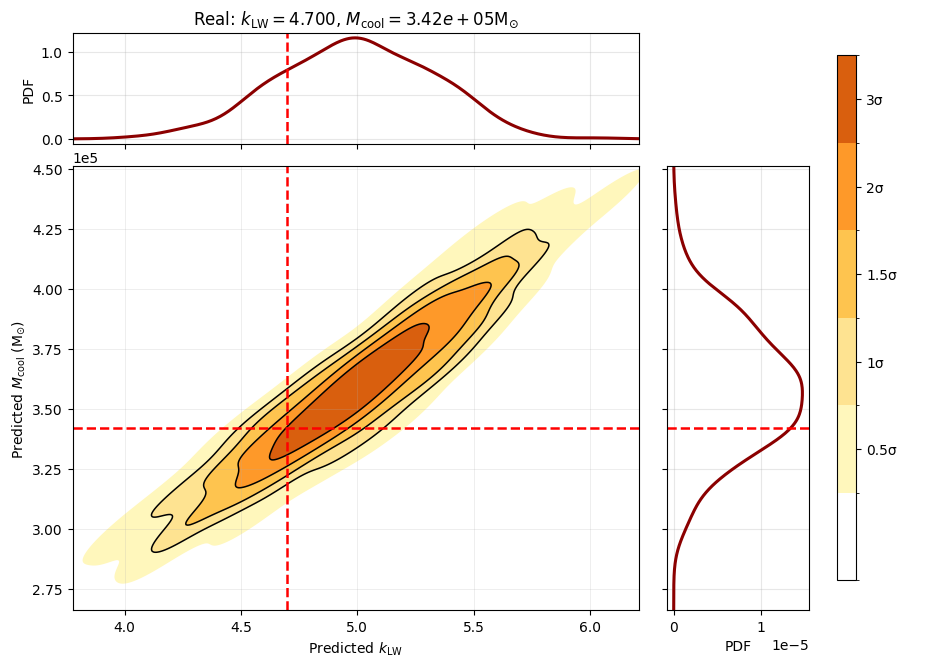


预测统计：
k_LW   = 4.993588 ± 0.328063
M_cool = 3.58665812e+05 ± 2.49379629e+04


In [ ]:
# ====================== 最终方案：σ 阶梯纯色填充（地形图风格） ======================

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==================== 样本选择（保持不变） ====================
tol = 1e-6
trues_rounded = np.round(trues, decimals=8)
unique_combinations = np.unique(trues_rounded, axis=0)
unique_combinations = unique_combinations[np.lexsort(
    (unique_combinations[:, 1], unique_combinations[:, 0]))
]

selected_real_pair = unique_combinations[35]
print(f"\n选中的样本组：")
print(f"真实 k_LW = {selected_real_pair[0]:.4f}")
print(f"真实 M_cool = {selected_real_pair[1]:.4e} M_⊙")

mask = np.all(np.isclose(trues, selected_real_pair, atol=tol), axis=1)
selected_predictions = predictions[mask]
sample_count = len(selected_predictions)
print(f"该组样本数量：{sample_count}")

pred_klw = selected_predictions[:, 0]
pred_mcool = selected_predictions[:, 1]

# ==================== 画布布局 ====================
fig = plt.figure(figsize=(9.5, 7.5))
gs = gridspec.GridSpec(
    2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
    wspace=0.08, hspace=0.08
)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ==================== 视野范围（完整 3.5σ） ====================
mean_klw, std_klw = np.mean(pred_klw), np.std(pred_klw)
mean_mcool, std_mcool = np.mean(pred_mcool), np.std(pred_mcool)

pad_sigma = 3.5
xmin = mean_klw - pad_sigma * std_klw
xmax = mean_klw + pad_sigma * std_klw
ymin = mean_mcool - pad_sigma * std_mcool
ymax = mean_mcool + pad_sigma * std_mcool

margin_x = 0.03 * (xmax - xmin)
margin_y = 0.03 * (ymax - ymin)
xmin -= margin_x
xmax += margin_x
ymin -= margin_y
ymax += margin_y

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# ==================== 2D KDE ====================
kde = gaussian_kde(np.vstack([pred_klw, pred_mcool]))
X, Y = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# ==================== σ 等概率区域计算（核心） ====================
Z_flat = Z.flatten()
idx = np.argsort(Z_flat)[::-1]
Z_sorted = Z_flat[idx]

cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]

sigma_probs = [0.393, 0.6827, 0.866, 0.9545, 0.9973]
pdf_levels = [Z_sorted[np.searchsorted(cdf, p)] for p in sigma_probs]

levels = [0.0] + sorted(pdf_levels) + [Z.max()]

# ==================== 离散纯色（地形图风格） ====================
sigma_colors = [
    "#ffffff",  # <0.5σ（背景）
    "#fff7bc",  # 0.5σ
    "#fee391",  # 1σ
    "#fec44f",  # 1.5σ
    "#fe9929",  # 2σ
    "#d95f0e",  # 3σ（核心）
]


cmap = ListedColormap(sigma_colors)
norm = BoundaryNorm(levels, cmap.N)

# ==================== 主图：σ 阶梯填色 ====================
cf = ax_main.contourf(
    X, Y, Z,
    levels=levels,
    cmap=cmap,
    norm=norm,
    antialiased=True
)

# σ 边界线（可选但强烈推荐）
ax_main.contour(
    X, Y, Z,
    levels=levels[2:-1],
    colors='k',
    linewidths=1.1
)

# ==================== 真实值 ====================
ax_main.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_main.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)

ax_main.set_xlabel('Predicted $k_{\\mathrm{LW}}$')
ax_main.set_ylabel('Predicted $M_{\\mathrm{cool}}$ ($\\mathrm{{M_{{\\odot}}}}$)')
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax_main.grid(True, alpha=0.3, lw=0.5)

# ==================== 上方 1D KDE ====================
kde_klw = gaussian_kde(pred_klw)
x_klw = np.linspace(xmin, xmax, 400)
ax_top.plot(x_klw, kde_klw(x_klw), color='darkred', lw=2.2)
ax_top.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_top.set_ylabel('PDF')
ax_top.set_title(
    f'Real: $k_{{\\mathrm{{LW}}}}={selected_real_pair[0]:.3f}$, '
    f'$M_{{\\mathrm{{cool}}}}={selected_real_pair[1]:.2e} \\mathrm{{M_{{\\odot}}}}$'
)
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# ==================== 右侧 1D KDE ====================
kde_mcool = gaussian_kde(pred_mcool)
y_mcool = np.linspace(ymin, ymax, 400)
ax_right.plot(kde_mcool(y_mcool), y_mcool, color='darkred', lw=2.2)
ax_right.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)
ax_right.set_xlabel('PDF')
ax_right.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3)

# ==================== 颜色条（σ 标注） ====================
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_ticks([
    (levels[i] + levels[i+1]) / 2 for i in range(1, 6)
])

cbar.set_ticklabels([
    '0.5σ', '1σ', '1.5σ', '2σ', '3σ'
])

cbar.set_label(' ')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('2d_prediction_density_noise_b.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

# ==================== 统计输出 ====================
print(f"\n预测统计：")
print(f"k_LW   = {mean_klw:.6f} ± {std_klw:.6f}")
print(f"M_cool = {mean_mcool:.8e} ± {std_mcool:.8e}")


In [23]:
import pandas as pd
import numpy as np

# --- k_LW 分组：收集所有预测值 ---
klw_groups = []  # 存储每组的信息

for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_preds = predictions[mask, 0]  # 该组所有预测的 k_LW 值
    
    if len(group_preds) > 0:  # 只保存有样本的组
        klw_groups.append({
            "k_LW_real": round(klw_real, 4),
            "sample_count": len(group_preds),
            "k_LW_pred_mean": np.mean(group_preds),
            "k_LW_pred_std": np.std(group_preds),
            "k_LW_pred_min": np.min(group_preds),
            "k_LW_pred_max": np.max(group_preds),
            "all_k_LW_predictions": group_preds.tolist()  # 保存所有单个预测值（列表）
        })

df_klw_full = pd.DataFrame(klw_groups)

# 保存为 CSV（pandas 会自动将列表转为字符串显示，但内容完整保留）
df_klw_full.to_csv("k_LW_group_stats_10000.csv", index=False)
print("已保存：k_LW_group_all_predictions.csv")
print(f"一共 {len(df_klw_full)} 个 k_LW 分组，每组所有预测值已完整保存。")
print(df_klw_full[['k_LW_real', 'sample_count', 'k_LW_pred_mean', 'k_LW_pred_std', 'k_LW_pred_min', 'k_LW_pred_max']])  # 预览统计列


# --- M_cool 分组：收集所有预测值 ---
mcool_groups = []

for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_preds = predictions[mask, 1]  # 该组所有预测的 M_cool 值
    
    if len(group_preds) > 0:
        mcool_groups.append({
            "M_cool_real": mcool_real,  # 科学计数法，保持原样
            "sample_count": len(group_preds),
            "M_cool_pred_mean": np.mean(group_preds),
            "M_cool_pred_std": np.std(group_preds),
            "M_cool_pred_min": np.min(group_preds),
            "M_cool_pred_max": np.max(group_preds),
            "all_M_cool_predictions": group_preds.tolist()  # 所有单个预测值
        })

df_mcool_full = pd.DataFrame(mcool_groups)

df_mcool_full.to_csv("M_cool_group_stats_10000.csv", index=False)
print("\n已保存：M_cool_group_stats_10000.csv")
print(f"一共 {len(df_mcool_full)} 个 M_cool 分组，每组所有预测值已完整保存。")
print(df_mcool_full[['M_cool_real', 'sample_count', 'M_cool_pred_mean', 'M_cool_pred_std', 'M_cool_pred_min', 'M_cool_pred_max']])


已保存：k_LW_group_all_predictions.csv
一共 54 个 k_LW 分组，每组所有预测值已完整保存。
    k_LW_real  sample_count  k_LW_pred_mean  k_LW_pred_std  k_LW_pred_min  \
0        0.04            18        0.911043       0.454570      -0.376970   
1        0.43            18        1.920314       0.246965       1.592604   
2        0.60            18        1.621309       0.368546       0.745864   
3        0.63            18        2.420343       0.289269       1.812804   
4        0.85            18        3.052084       0.320980       2.455080   
5        0.89            18        1.895348       0.312496       1.316702   
6        0.92            18        0.908845       0.374250       0.290887   
7        0.94            18        1.997183       0.295698       1.418914   
8        1.10            18        2.853177       0.349872       2.076434   
9        1.28            18        1.713838       0.291738       1.175502   
10       1.49            18        3.543765       0.317832       3.046899   
11       1.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

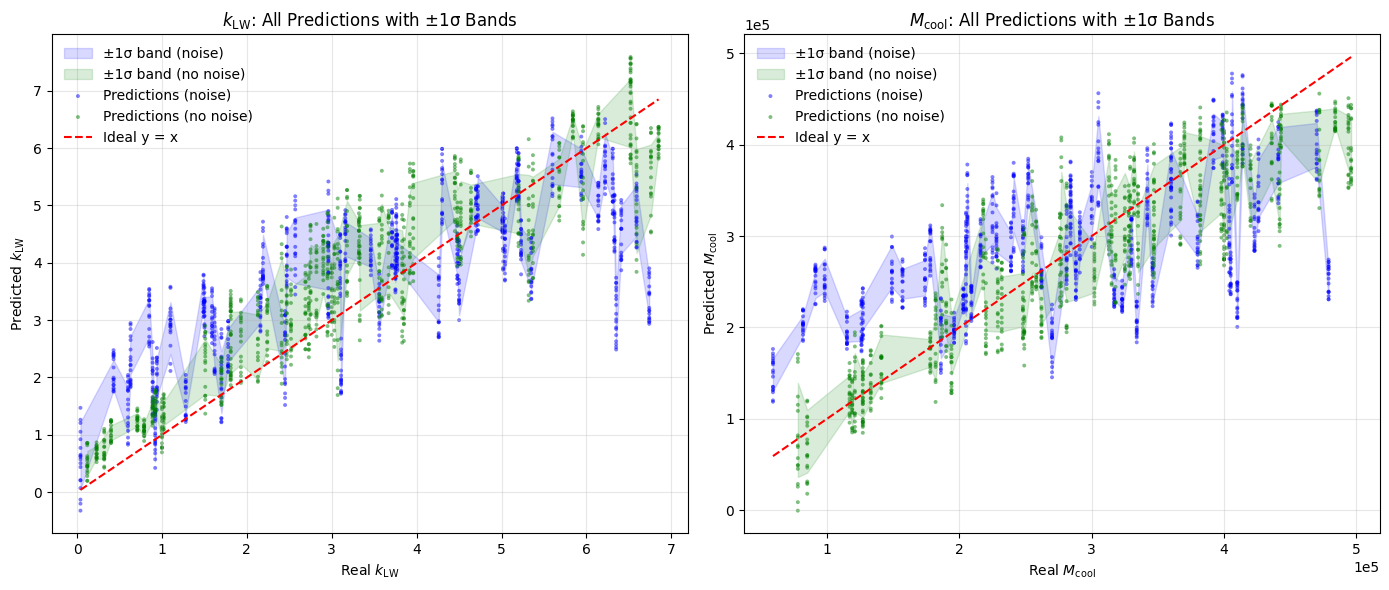

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# MODIFIED: 设置学术论文字体和样式（全局配置）
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样，未改动任何一个）
df_k           = pd.read_csv("k_LW_group_stats_10000.csv")      # 有噪音
df_k_nonoise   = pd.read_csv("k_LW_group_stats_nonoise.csv")    # 无噪音
df_m           = pd.read_csv("M_cool_group_stats_10000.csv")    # 有噪音
df_m_nonoise   = pd.read_csv("M_cool_group_stats_nonoise.csv")  # 无噪音

# 当前CSV已直接包含 mean 和 std 列，无需再添加或近似

# 创建画布
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========== 第一张：k_LW ==========
ax = axes[0]

# 有噪音 - 1σ 误差棒（蓝色实心圆点）
valid_k = df_k['k_LW_pred_std'] > 0
ax.errorbar(df_k.loc[valid_k, "k_LW_real"], df_k.loc[valid_k, "k_LW_pred_mean"],
            yerr=df_k.loc[valid_k, "k_LW_pred_std"], fmt='o', capsize=3, color="blue",
            linewidth=1, elinewidth=1, label="1σ Predicted (noise)", markerfacecolor='blue')

# 有噪音 - max-min 范围（蓝色空心方块）
mid_k = (df_k["k_LW_pred_min"] + df_k["k_LW_pred_max"]) / 2
err_k = (df_k["k_LW_pred_max"] - df_k["k_LW_pred_min"]) / 2
ax.errorbar(df_k["k_LW_real"], mid_k, yerr=err_k,
            fmt='s', capsize=5, label="Max-Min Predicted (noise)", color="green",
            markerfacecolor='none', linewidth=1.5, elinewidth=1.5)

# 无噪音 - 1σ 误差棒（绿色实心圆点）
valid_k_n = df_k_nonoise['k_LW_pred_std'] > 0
ax.errorbar(df_k_nonoise.loc[valid_k_n, "k_LW_real"], df_k_nonoise.loc[valid_k_n, "k_LW_pred_mean"],
            yerr=df_k_nonoise.loc[valid_k_n, "k_LW_pred_std"], fmt='o', capsize=3, color="red",
            linewidth=1, elinewidth=1, label="1σ Predicted (no noise)", markerfacecolor='red')

# 无噪音 - max-min 范围（绿色空心方块）
mid_k_n = (df_k_nonoise["k_LW_pred_min"] + df_k_nonoise["k_LW_pred_max"]) / 2
err_k_n = (df_k_nonoise["k_LW_pred_max"] - df_k_nonoise["k_LW_pred_min"]) / 2
ax.errorbar(df_k_nonoise["k_LW_real"], mid_k_n, yerr=err_k_n,
            fmt='s', capsize=5, label="Max-Min Predicted (no noise)", color="orange",
            markerfacecolor='none', linewidth=1.5, elinewidth=1.5)

# 理想线 y=x
ax.plot(df_k["k_LW_real"], df_k["k_LW_real"], 'r--', lw=1.5, label='Ideal y=x')

ax.set_xlabel("Real $k_{\\mathrm{LW}}$")
ax.set_ylabel("Predicted $k_{\\mathrm{LW}}$")
ax.set_title("$k_{\\mathrm{LW}}$ Prediction Range (with / without noise)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

# ========== 第二张：M_cool ==========
ax = axes[1]

# 有噪音 - 1σ
valid_m = df_m['M_cool_pred_std'] > 0
ax.errorbar(df_m.loc[valid_m, "M_cool_real"], df_m.loc[valid_m, "M_cool_pred_mean"],
            yerr=df_m.loc[valid_m, "M_cool_pred_std"], fmt='o', capsize=3, color="blue",
            linewidth=1, elinewidth=1, label="1σ Predicted (noise)", markerfacecolor='blue')

# 有噪音 - max-min
mid_m = (df_m["M_cool_pred_min"] + df_m["M_cool_pred_max"]) / 2
err_m = (df_m["M_cool_pred_max"] - df_m["M_cool_pred_min"]) / 2
ax.errorbar(df_m["M_cool_real"], mid_m, yerr=err_m,
            fmt='s', capsize=5, label="Max-Min Predicted (noise)", color="green",
            markerfacecolor='none', linewidth=1.5, elinewidth=1.5)

# 无噪音 - 1σ
valid_m_n = df_m_nonoise['M_cool_pred_std'] > 0
ax.errorbar(df_m_nonoise.loc[valid_m_n, "M_cool_real"], df_m_nonoise.loc[valid_m_n, "M_cool_pred_mean"],
            yerr=df_m_nonoise.loc[valid_m_n, "M_cool_pred_std"], fmt='o', capsize=3, color="red",
            linewidth=1, elinewidth=1, label="1σ Predicted (no noise)", markerfacecolor='red')

# 无噪音 - max-min
mid_m_n = (df_m_nonoise["M_cool_pred_min"] + df_m_nonoise["M_cool_pred_max"]) / 2
err_m_n = (df_m_nonoise["M_cool_pred_max"] - df_m_nonoise["M_cool_pred_min"]) / 2
ax.errorbar(df_m_nonoise["M_cool_real"], mid_m_n, yerr=err_m_n,
            fmt='s', capsize=5, label="Max-Min Predicted (no noise)", color="orange",
            markerfacecolor='none', linewidth=1.5, elinewidth=1.5)

# 理想线 y=x
ax.plot(df_m["M_cool_real"], df_m["M_cool_real"], 'r--', lw=1.5, label='Ideal y=x')

ax.set_xlabel("Real $M_{\\mathrm{cool}}$")
ax.set_ylabel("Predicted $M_{\\mathrm{cool}}$")
ax.set_title("$M_{\\mathrm{cool}}$ Prediction Range (with / without noise)")
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("error_bar_plot_combined_10000.png", dpi=300, bbox_inches='tight')
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

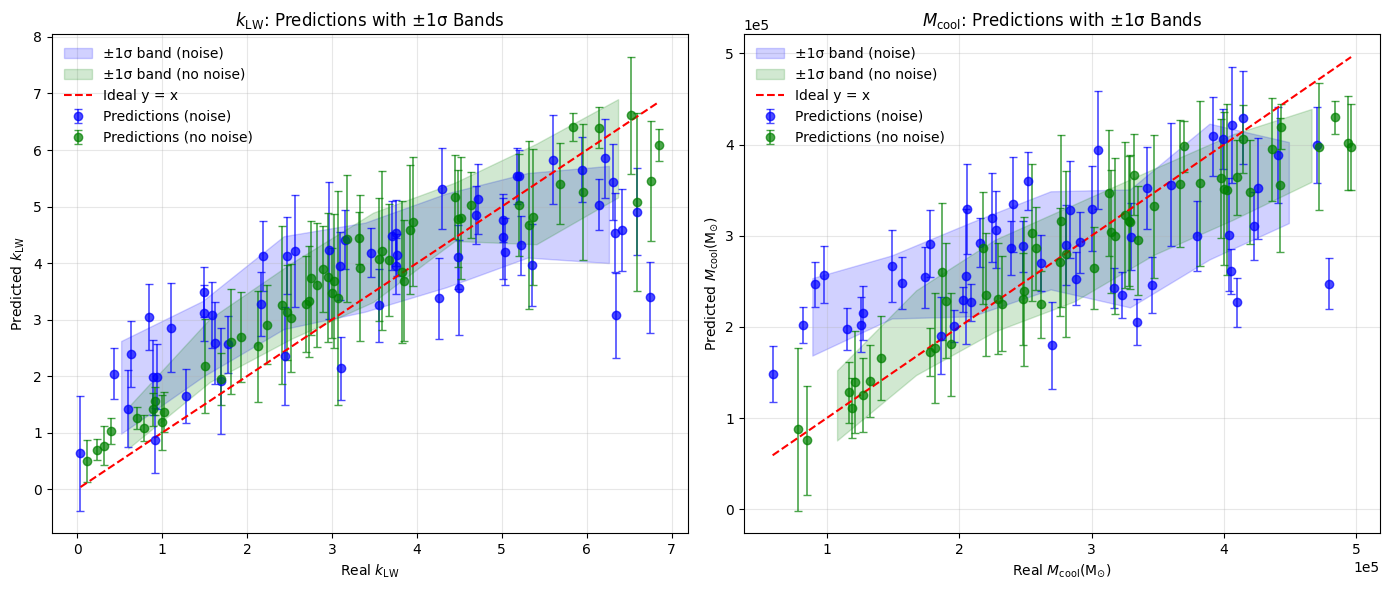

In [85]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样）
df_k           = pd.read_csv("k_LW_group_stats_10000.csv")      # 有噪音
df_k_nonoise   = pd.read_csv("k_LW_group_stats_nonoise.csv")    # 无噪音
df_m           = pd.read_csv("M_cool_group_stats_10000.csv")    # 有噪音
df_m_nonoise   = pd.read_csv("M_cool_group_stats_nonoise.csv")  # 无噪音

# --------------------- 函数：生成散点 + 7bin平滑色带（完整覆盖范围） ---------------------
def generate_scatter_and_full_bands(df, real_col, min_col, max_col, count_col, nbins=7):
    df_valid = df.dropna(subset=[min_col, max_col, count_col])
    
    real_values = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    counts = df_valid[count_col].values.astype(int)
    
    # 生成模拟散点（用于计算色带）
    real_scatter = []
    pred_scatter = []
    for r, pmin, pmax, n in zip(real_values, pred_min, pred_max, counts):
        if n > 0:
            preds = np.random.uniform(pmin, pmax, size=n)
            real_scatter.extend([r] * n)
            pred_scatter.extend(preds)
    real_scatter = np.array(real_scatter)
    pred_scatter = np.array(pred_scatter)
    
    if len(real_scatter) == 0:
        return real_scatter, pred_scatter, [], [], [], real_values, pred_min, pred_max
    
    # 7个均匀bin，覆盖全部真实值范围
    overall_min = real_scatter.min()
    overall_max = real_scatter.max()
    bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    lowers = np.full(nbins, np.nan)
    uppers = np.full(nbins, np.nan)
    
    for i in range(nbins):
        mask = (real_scatter >= bin_edges[i]) & (real_scatter < bin_edges[i+1])
        if np.sum(mask) > 1:
            group = pred_scatter[mask]
            mean = np.mean(group)
            std = np.std(group)
            lowers[i] = mean - std
            uppers[i] = mean + std
    
    return real_scatter, pred_scatter, bin_centers, lowers, uppers, real_values, pred_min, pred_max

# --------------------- 处理 k_LW ---------------------
(real_k_noise, pred_k_noise, bins_k_noise, low_k_noise, up_k_noise,
 real_vals_k_noise, min_k_noise, max_k_noise) = generate_scatter_and_full_bands(
    df_k, "k_LW_real", "k_LW_pred_min", "k_LW_pred_max", "sample_count", nbins=7)

(real_k_nonoise, pred_k_nonoise, bins_k_nonoise, low_k_nonoise, up_k_nonoise,
 real_vals_k_nonoise, min_k_nonoise, max_k_nonoise) = generate_scatter_and_full_bands(
    df_k_nonoise, "k_LW_real", "k_LW_pred_min", "k_LW_pred_max", "sample_count", nbins=7)

# --------------------- 处理 M_cool ---------------------
(real_m_noise, pred_m_noise, bins_m_noise, low_m_noise, up_m_noise,
 real_vals_m_noise, min_m_noise, max_m_noise) = generate_scatter_and_full_bands(
    df_m, "M_cool_real", "M_cool_pred_min", "M_cool_pred_max", "sample_count", nbins=7)

(real_m_nonoise, pred_m_nonoise, bins_m_nonoise, low_m_nonoise, up_m_nonoise,
 real_vals_m_nonoise, min_m_nonoise, max_m_nonoise) = generate_scatter_and_full_bands(
    df_m_nonoise, "M_cool_real", "M_cool_pred_min", "M_cool_pred_max", "sample_count", nbins=7)

# --------------------- 绘图 ---------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========== 左图：k_LW ==========
ax = axes[0]

# 色带完整延伸覆盖整个横坐标范围
ax.fill_between(bins_k_noise, low_k_noise, up_k_noise, color='blue', alpha=0.18, label='±1σ band (noise)')
ax.fill_between(bins_k_nonoise, low_k_nonoise, up_k_nonoise, color='green', alpha=0.18, label='±1σ band (no noise)')

# errorbar 替代散点
mid_k_noise = (min_k_noise + max_k_noise) / 2
err_k_noise = (max_k_noise - min_k_noise) / 2
ax.errorbar(real_vals_k_noise, mid_k_noise, yerr=err_k_noise, fmt='o', color='blue', alpha=0.7,
            capsize=3, markersize=6, elinewidth=1.2, label='Predictions (noise)')

mid_k_nonoise = (min_k_nonoise + max_k_nonoise) / 2
err_k_nonoise = (max_k_nonoise - min_k_nonoise) / 2
ax.errorbar(real_vals_k_nonoise, mid_k_nonoise, yerr=err_k_nonoise, fmt='o', color='green', alpha=0.7,
            capsize=3, markersize=6, elinewidth=1.2, label='Predictions (no noise)')

# 理想线（覆盖全范围）
overall_xmin_k = min(real_k_noise.min() if len(real_k_noise) else np.inf,
                     real_k_nonoise.min() if len(real_k_nonoise) else np.inf)
overall_xmax_k = max(real_k_noise.max() if len(real_k_noise) else -np.inf,
                     real_k_nonoise.max() if len(real_k_nonoise) else -np.inf)
if np.isfinite(overall_xmin_k) and np.isfinite(overall_xmax_k):
    ax.plot([overall_xmin_k, overall_xmax_k], [overall_xmin_k, overall_xmax_k], 'r--', lw=1.5, label='Ideal y = x')

ax.set_xlabel('Real $k_{\\mathrm{LW}}$')
ax.set_ylabel('Predicted $k_{\\mathrm{LW}}$')
ax.set_title('$k_{\\mathrm{LW}}$: Predictions with ±1σ Bands')
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

# ========== 右图：M_cool ==========
ax = axes[1]

ax.fill_between(bins_m_noise, low_m_noise, up_m_noise, color='blue', alpha=0.18, label='±1σ band (noise)')
ax.fill_between(bins_m_nonoise, low_m_nonoise, up_m_nonoise, color='green', alpha=0.18, label='±1σ band (no noise)')

mid_m_noise = (min_m_noise + max_m_noise) / 2
err_m_noise = (max_m_noise - min_m_noise) / 2
ax.errorbar(real_vals_m_noise, mid_m_noise, yerr=err_m_noise, fmt='o', color='blue', alpha=0.7,
            capsize=3, markersize=6, elinewidth=1.2, label='Predictions (noise)')

mid_m_nonoise = (min_m_nonoise + max_m_nonoise) / 2
err_m_nonoise = (max_m_nonoise - min_m_nonoise) / 2
ax.errorbar(real_vals_m_nonoise, mid_m_nonoise, yerr=err_m_nonoise, fmt='o', color='green', alpha=0.7,
            capsize=3, markersize=6, elinewidth=1.2, label='Predictions (no noise)')

overall_xmin_m = min(real_m_noise.min() if len(real_m_noise) else np.inf,
                     real_m_nonoise.min() if len(real_m_nonoise) else np.inf)
overall_xmax_m = max(real_m_noise.max() if len(real_m_noise) else -np.inf,
                     real_m_nonoise.max() if len(real_m_nonoise) else -np.inf)
if np.isfinite(overall_xmin_m) and np.isfinite(overall_xmax_m):
    ax.plot([overall_xmin_m, overall_xmax_m], [overall_xmin_m, overall_xmax_m], 'r--', lw=1.5, label='Ideal y = x')

ax.set_xlabel('Real $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$')
ax.set_ylabel('Predicted $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$')
ax.set_title('$M_{\\mathrm{cool}}$: Predictions with ±1σ Bands')
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('scatter_with_sigma_bands.png', dpi=300, bbox_inches='tight')
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

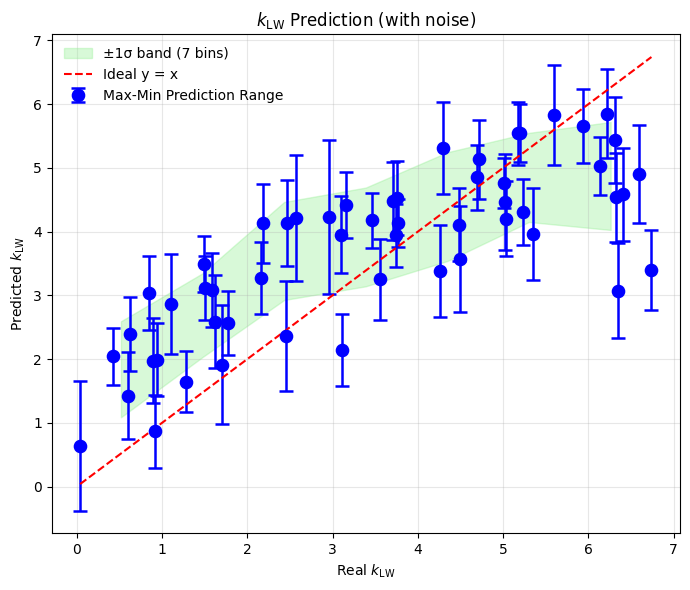

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

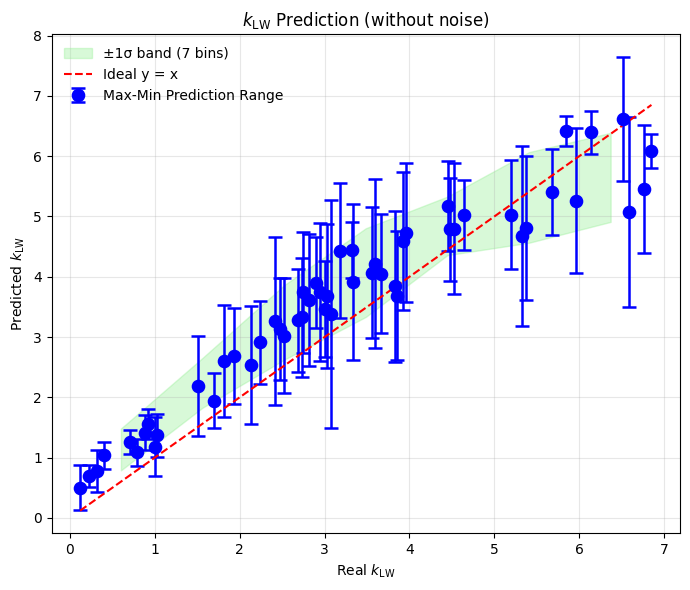

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

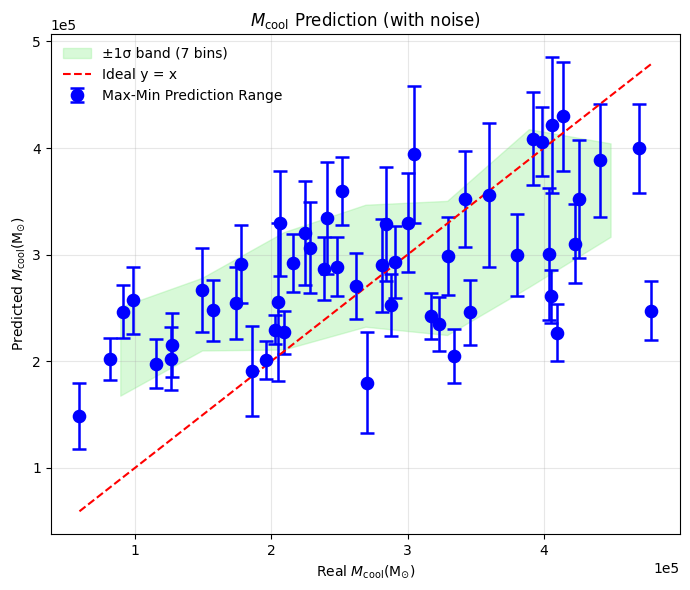

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

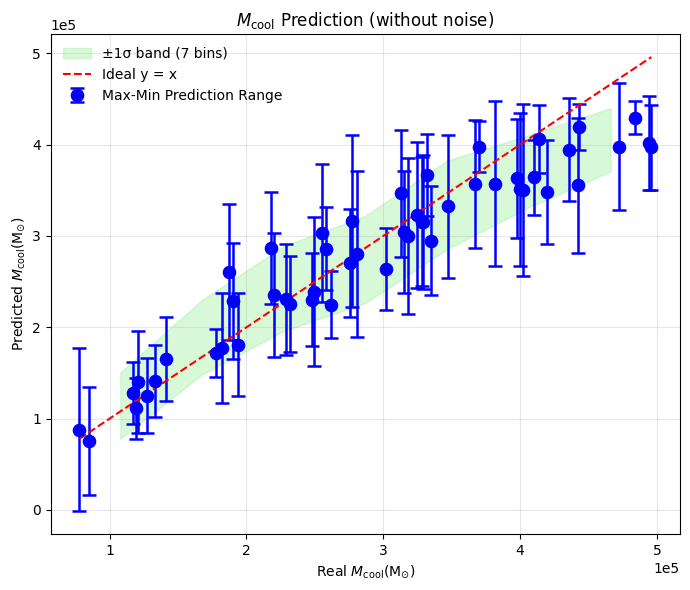

In [86]:
# ====================== 新代码块：四张独立图（Max-Min errorbar 实心中心 + 7bin 1σ色带） ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样）
df_k           = pd.read_csv("k_LW_group_stats_10000.csv")      # 有噪音
df_k_nonoise   = pd.read_csv("k_LW_group_stats_nonoise.csv")    # 无噪音
df_m           = pd.read_csv("M_cool_group_stats_10000.csv")    # 有噪音
df_m_nonoise   = pd.read_csv("M_cool_group_stats_nonoise.csv")  # 无噪音

# --------------------- 函数：绘制单张独立图（Max-Min errorbar 实心中心） ---------------------
def plot_maxmin_with_sigma_band(df, real_col, min_col, max_col, mean_col, std_col,
                                title, xlabel, ylabel, filename, use_sci=False, nbins=7):
    df_valid = df.dropna(subset=[min_col, max_col])
    
    if len(df_valid) == 0:
        print(f"警告：{filename} 无有效数据")
        return
    
    real = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    pred_mean = df_valid[mean_col].values if mean_col in df_valid else (pred_min + pred_max)/2
    pred_std = df_valid[std_col].values if std_col in df_valid else np.zeros_like(pred_min)
    
    # 创建图片
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # === 7个均匀bin的平滑 ±1σ 色带 ===
    overall_min = real.min()
    overall_max = real.max()
    bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    lowers = np.full(nbins, np.nan)
    uppers = np.full(nbins, np.nan)
    
    for i in range(nbins):
        mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
        if np.sum(mask) > 1:
            bin_means = pred_mean[mask]
            bin_stds = pred_std[mask]
            combined_mean = np.mean(bin_means)
            combined_std = np.sqrt(np.mean(bin_stds**2) + np.var(bin_means))
            lowers[i] = combined_mean - combined_std
            uppers[i] = combined_mean + combined_std
    
    ax.fill_between(bin_centers, lowers, uppers, color='lightgreen', alpha=0.35, label='±1σ band (7 bins)')
    
    # === Max-Min Prediction Range errorbar（中心实心圆点）===
    mid = (pred_min + pred_max) / 2
    err = (pred_max - pred_min) / 2
    ax.errorbar(real, mid, yerr=err,
                fmt='o', color='blue', capsize=5, markersize=8,
                markerfacecolor='blue', markeredgewidth=1.8, elinewidth=1.8,  # 实心中心 + 粗边/棒
                label='Max-Min Prediction Range')
    
    # 理想线
    ax.plot([overall_min, overall_max], [overall_min, overall_max], 'r--', lw=1.5, label='Ideal y = x')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if use_sci:
        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --------------------- 绘制四张独立图 ---------------------

# 1. k_LW 有噪音
plot_maxmin_with_sigma_band(
    df_k,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title="$k_{\\mathrm{LW}}$ Prediction (with noise)",
    xlabel="Real $k_{\\mathrm{LW}}$",
    ylabel="Predicted $k_{\\mathrm{LW}}$",
    filename="kLW_with_noise_maxmin_filled.png"
)

# 2. k_LW 无噪音
plot_maxmin_with_sigma_band(
    df_k_nonoise,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title="$k_{\\mathrm{LW}}$ Prediction (without noise)",
    xlabel="Real $k_{\\mathrm{LW}}$",
    ylabel="Predicted $k_{\\mathrm{LW}}$",
    filename="kLW_without_noise_maxmin_filled.png"
)

# 3. M_cool 有噪音
plot_maxmin_with_sigma_band(
    df_m,
    real_col="M_cool_real",
    min_col="M_cool_pred_min",
    max_col="M_cool_pred_max",
    mean_col="M_cool_pred_mean",
    std_col="M_cool_pred_std",
    title="$M_{\\mathrm{cool}}$ Prediction (with noise)",
    xlabel="Real $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    ylabel="Predicted $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    filename="Mcool_with_noise_maxmin_filled.png",
    use_sci=True
)

# 4. M_cool 无噪音
plot_maxmin_with_sigma_band(
    df_m_nonoise,
    real_col="M_cool_real",
    min_col="M_cool_pred_min",
    max_col="M_cool_pred_max",
    mean_col="M_cool_pred_mean",
    std_col="M_cool_pred_std",
    title="$M_{\\mathrm{cool}}$ Prediction (without noise)",
    xlabel="Real $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    ylabel="Predicted $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    filename="Mcool_without_noise_maxmin_filled.png",
    use_sci=True
)